Modelo 1 - Clasificación Binaria (Churn Yes/No)

Importar librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam as KerasAdam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

 Cargar datos

In [2]:
df = pd.read_csv(r"C:\Users\Jesus\Downloads\ANN Regresión-20260529\customer_clean.csv")
X = df.drop('Churn', axis=1)
y = df['Churn']

SMOTE

In [3]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

Escalar

In [4]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

 Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res_scaled, y_res, test_size=0.2, random_state=42)

Modelo

In [6]:
model_class = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_class.compile(
    optimizer=KerasAdam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_class = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
reduce_lr_class = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-6)

history_class = model_class.fit(
    X_train, y_train, epochs=400, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_class, reduce_lr_class], verbose=1
)

Epoch 1/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7620 - loss: 0.4921 - val_accuracy: 0.8136 - val_loss: 0.4094 - learning_rate: 3.0000e-04
Epoch 2/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8087 - loss: 0.4136 - val_accuracy: 0.8228 - val_loss: 0.3798 - learning_rate: 3.0000e-04
Epoch 3/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8205 - loss: 0.3899 - val_accuracy: 0.8185 - val_loss: 0.3723 - learning_rate: 3.0000e-04
Epoch 4/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8304 - loss: 0.3677 - val_accuracy: 0.8316 - val_loss: 0.3637 - learning_rate: 3.0000e-04
Epoch 5/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8304 - loss: 0.3638 - val_accuracy: 0.8398 - val_loss: 0.3561 - learning_rate: 3.0000e-04
Epoch 6/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8305 - loss: 0.3606 - val_accuracy: 0.8417 - val_loss: 0.3523 - learning_rate: 3.0000e-04
Epoch 7/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - 

Evaluación

In [7]:
loss_class, acc_class = model_class.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Clasificación - Accuracy: {acc_class:.2f}")

Modelo Clasificación - Accuracy: 0.84


In [9]:
from sklearn.metrics import classification_report

y_pred_class = (model_class.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1037
           1       0.86      0.81      0.84      1029

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066



Visualizaciones

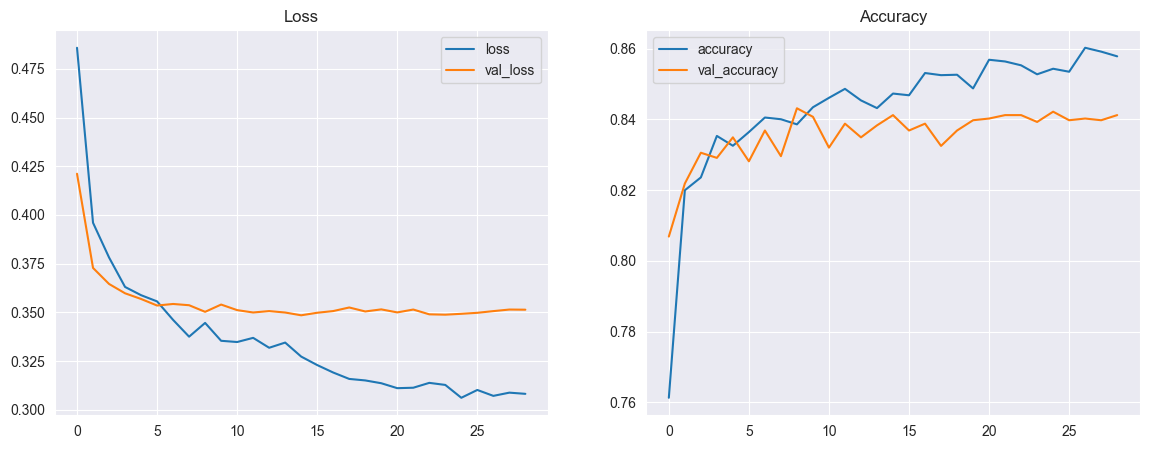

In [8]:
model_loss = pd.DataFrame(history_class.history)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
model_loss[['loss','val_loss']].plot(ax=axes[0], title='Loss')
model_loss[['accuracy','val_accuracy']].plot(ax=axes[1], title='Accuracy')
plt.show()

 Guardar

In [9]:
model_class.save("model_churn_class.keras")
print("Modelo clasificación guardado ")

Modelo clasificación guardado 
